# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

# Task 1 — Load the Dataset

In [2]:
df = pd.read_csv('Ecommerce_Customers.csv')

# Task 2 — Explore the Data

In [9]:
print("HEAD:")
df.head()

HEAD:


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [10]:
print("\nINFO:")
df.info()


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [11]:
print("\nDESCRIBE:")
df.describe()


DESCRIBE:


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


# Task 3 — Data Cleaning

In [16]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Drop non-numeric columns not useful for modeling
df_clean = df.drop(columns=['Email', 'Address', 'Avatar'])
print("\nCleaned DataFrame shape:", df_clean.shape)
print(df_clean.head())

Missing values:
 Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Duplicate rows: 0

Cleaned DataFrame shape: (500, 5)
   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    13.717514        36.721283              3.120179   
4            33.330673    12.795189        37.536653              4.446308   

   Yearly Amount Spent  
0           587.951054  
1           392.204933  
2           487.547505  
3           581.852344  
4           599.406092  


# Task 4 — Feature Engineering

## Step 4.1 — App-to-Website Ratio

Captures how much more a customer prefers the App over the Website.
A higher ratio means the customer is more App-oriented.

In [19]:
df_clean['App_to_Web_Ratio'] = df_clean['Time on App'] / df_clean['Time on Website']

print("Feature 1: App_to_Web_Ratio")
print(df_clean[['Time on App', 'Time on Website', 'App_to_Web_Ratio']].head())
print("\nStats:")
print(df_clean['App_to_Web_Ratio'].describe())

Feature 1: App_to_Web_Ratio
   Time on App  Time on Website  App_to_Web_Ratio
0    12.655651        39.577668          0.319767
1    11.109461        37.268959          0.298089
2    11.330278        37.110597          0.305311
3    13.717514        36.721283          0.373558
4    12.795189        37.536653          0.340872

Stats:
count    500.000000
mean       0.325392
std        0.027552
min        0.239920
25%        0.307080
50%        0.325436
75%        0.347177
max        0.407103
Name: App_to_Web_Ratio, dtype: float64


## Step 4.2 — Engagement Score

Combines Avg. Session Length and Time on App.
Customers with longer and more frequent app sessions are likely
more engaged and may spend more annually.

In [20]:
df_clean['Engagement_Score'] = df_clean['Avg. Session Length'] * df_clean['Time on App']

print("Feature 2: Engagement_Score")
print(df_clean[['Avg. Session Length', 'Time on App', 'Engagement_Score']].head())
print("\nStats:")
print(df_clean['Engagement_Score'].describe())

Feature 2: Engagement_Score
   Avg. Session Length  Time on App  Engagement_Score
0            34.497268    12.655651        436.585386
1            31.926272    11.109461        354.683665
2            33.000915    11.330278        373.909540
3            34.305557    13.717514        470.586942
4            33.330673    12.795189        426.472239

Stats:
count    500.000000
mean     398.345812
std       34.744771
min      290.147375
25%      374.667887
50%      397.488794
75%      421.907493
max      519.979205
Name: Engagement_Score, dtype: float64


## Step 4.3 — Membership Tier (Discretization / Binning)

Instead of using raw membership years, we group customers into
meaningful tiers — similar to how businesses classify customers.  
   New     : membership < 2 years  
   Regular : 2 - 4 years  
   Loyal   : > 4 years  


In [21]:
df_clean['Membership_Tier'] = pd.cut(
    df_clean['Length of Membership'],
    bins=[0, 2, 4, float('inf')],
    labels=['New', 'Regular', 'Loyal']
)

print("Feature 3: Membership_Tier")
print(df_clean[['Length of Membership', 'Membership_Tier']].head())
print("\nValue counts:")
print(df_clean['Membership_Tier'].value_counts())

Feature 3: Membership_Tier
   Length of Membership Membership_Tier
0              4.082621           Loyal
1              2.664034         Regular
2              4.104543           Loyal
3              3.120179         Regular
4              4.446308           Loyal

Value counts:
Membership_Tier
Regular    307
Loyal      158
New         35
Name: count, dtype: int64


## Step 4.4 — Loyalty × App Interaction Feature

Captures the combined effect of being a long-term member AND
spending a lot of time on the app. A loyal customer who uses the
app heavily is likely a high spender.

In [26]:
df_clean['Loyalty_x_App'] = df_clean['Length of Membership'] * df_clean['Time on App']

print("Feature 4: Loyalty_x_App")
print(df_clean[['Length of Membership', 'Time on App', 'Loyalty_x_App']].head())
print("\nStats:")
print(df_clean['Loyalty_x_App'].describe())

Feature 4: Loyalty_x_App
   Length of Membership  Time on App  Loyalty_x_App
0              4.082621    12.655651      51.668223
1              2.664034    11.109461      29.595983
2              4.104543    11.330278      46.505616
3              3.120179    13.717514      42.801095
4              4.446308    12.795189      56.891353

Stats:
count    500.000000
mean      42.615898
std       12.747215
min        3.388907
25%       34.602943
50%       42.423270
75%       50.610042
max       84.507335
Name: Loyalty_x_App, dtype: float64


## Step 4.5 — Summary of All Engineered Features

In [23]:
print("All columns after feature engineering:")
print(df_clean.columns.tolist())

print("\nFinal DataFrame shape:", df_clean.shape)
print("\nSample of new features:")
df_clean[['App_to_Web_Ratio', 'Engagement_Score',
          'Membership_Tier', 'Loyalty_x_App']].head()

All columns after feature engineering:
['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent', 'App_to_Web_Ratio', 'Engagement_Score', 'Membership_Tier', 'Loyalty_x_App']

Final DataFrame shape: (500, 9)

Sample of new features:


,App_to_Web_Ratio,Engagement_Score,Membership_Tier,Loyalty_x_App
0,0.319767,436.585386,Loyal,51.668223
1,0.298089,354.683665,Regular,29.595983
2,0.305311,373.909540,Loyal,46.505616
3,0.373558,470.586942,Regular,42.801095
4,0.340872,426.472239,Loyal,56.891353


# Task 5 — Prepare Data for Modeling

## Step 5.1 — Handle the Categorical Feature (Membership_Tier)

Linear Regression cannot work with text/category columns.
We use get_dummies() to convert Membership_Tier into binary columns.
drop_first=True avoids the dummy variable trap (multicollinearity).

In [28]:
df_model = pd.get_dummies(df_clean, columns=['Membership_Tier'], drop_first=True)

print("Columns after encoding:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)

# Check which dummy columns were actually created
dummy_cols = [c for c in df_model.columns if 'Membership_Tier' in c]
print("\nDummy columns created:", dummy_cols)
print("\nSample of encoded columns:")
print(df_model[dummy_cols].head())

Columns after encoding:
['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent', 'App_to_Web_Ratio', 'Engagement_Score', 'Loyalty_x_App', 'Membership_Tier_Regular', 'Membership_Tier_Loyal']

Shape: (500, 10)

Dummy columns created: ['Membership_Tier_Regular', 'Membership_Tier_Loyal']

Sample of encoded columns:
   Membership_Tier_Regular  Membership_Tier_Loyal
0                    False                   True
1                     True                  False
2                    False                   True
3                     True                  False
4                    False                   True


## Step 5.2 — Define X and y

X contains all columns except the target variable.
y is what we are trying to predict: Yearly Amount Spent.

In [29]:
X = df_model.drop('Yearly Amount Spent', axis=1)
y = df_model['Yearly Amount Spent']

print("Feature columns (X):")
print(X.columns.tolist())
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())

Feature columns (X):
['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'App_to_Web_Ratio', 'Engagement_Score', 'Loyalty_x_App', 'Membership_Tier_Regular', 'Membership_Tier_Loyal']

X shape: (500, 9)
y shape: (500,)

First 5 rows of X:
   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    13.717514        36.721283              3.120179   
4            33.330673    12.795189        37.536653              4.446308   

   App_to_Web_Ratio  Engagement_Score  Loyalty_x_App  Membership_Tier_Regular  \
0          0.319767        436.585386      51.668223                    False   
1          0.298089        354.683665      29.595983                     True   
2          0.305311  

## Step 5.3 — Correlation Analysis

Check how strongly each feature correlates with the target.
This helps us understand which features are most predictive
before even training the model.

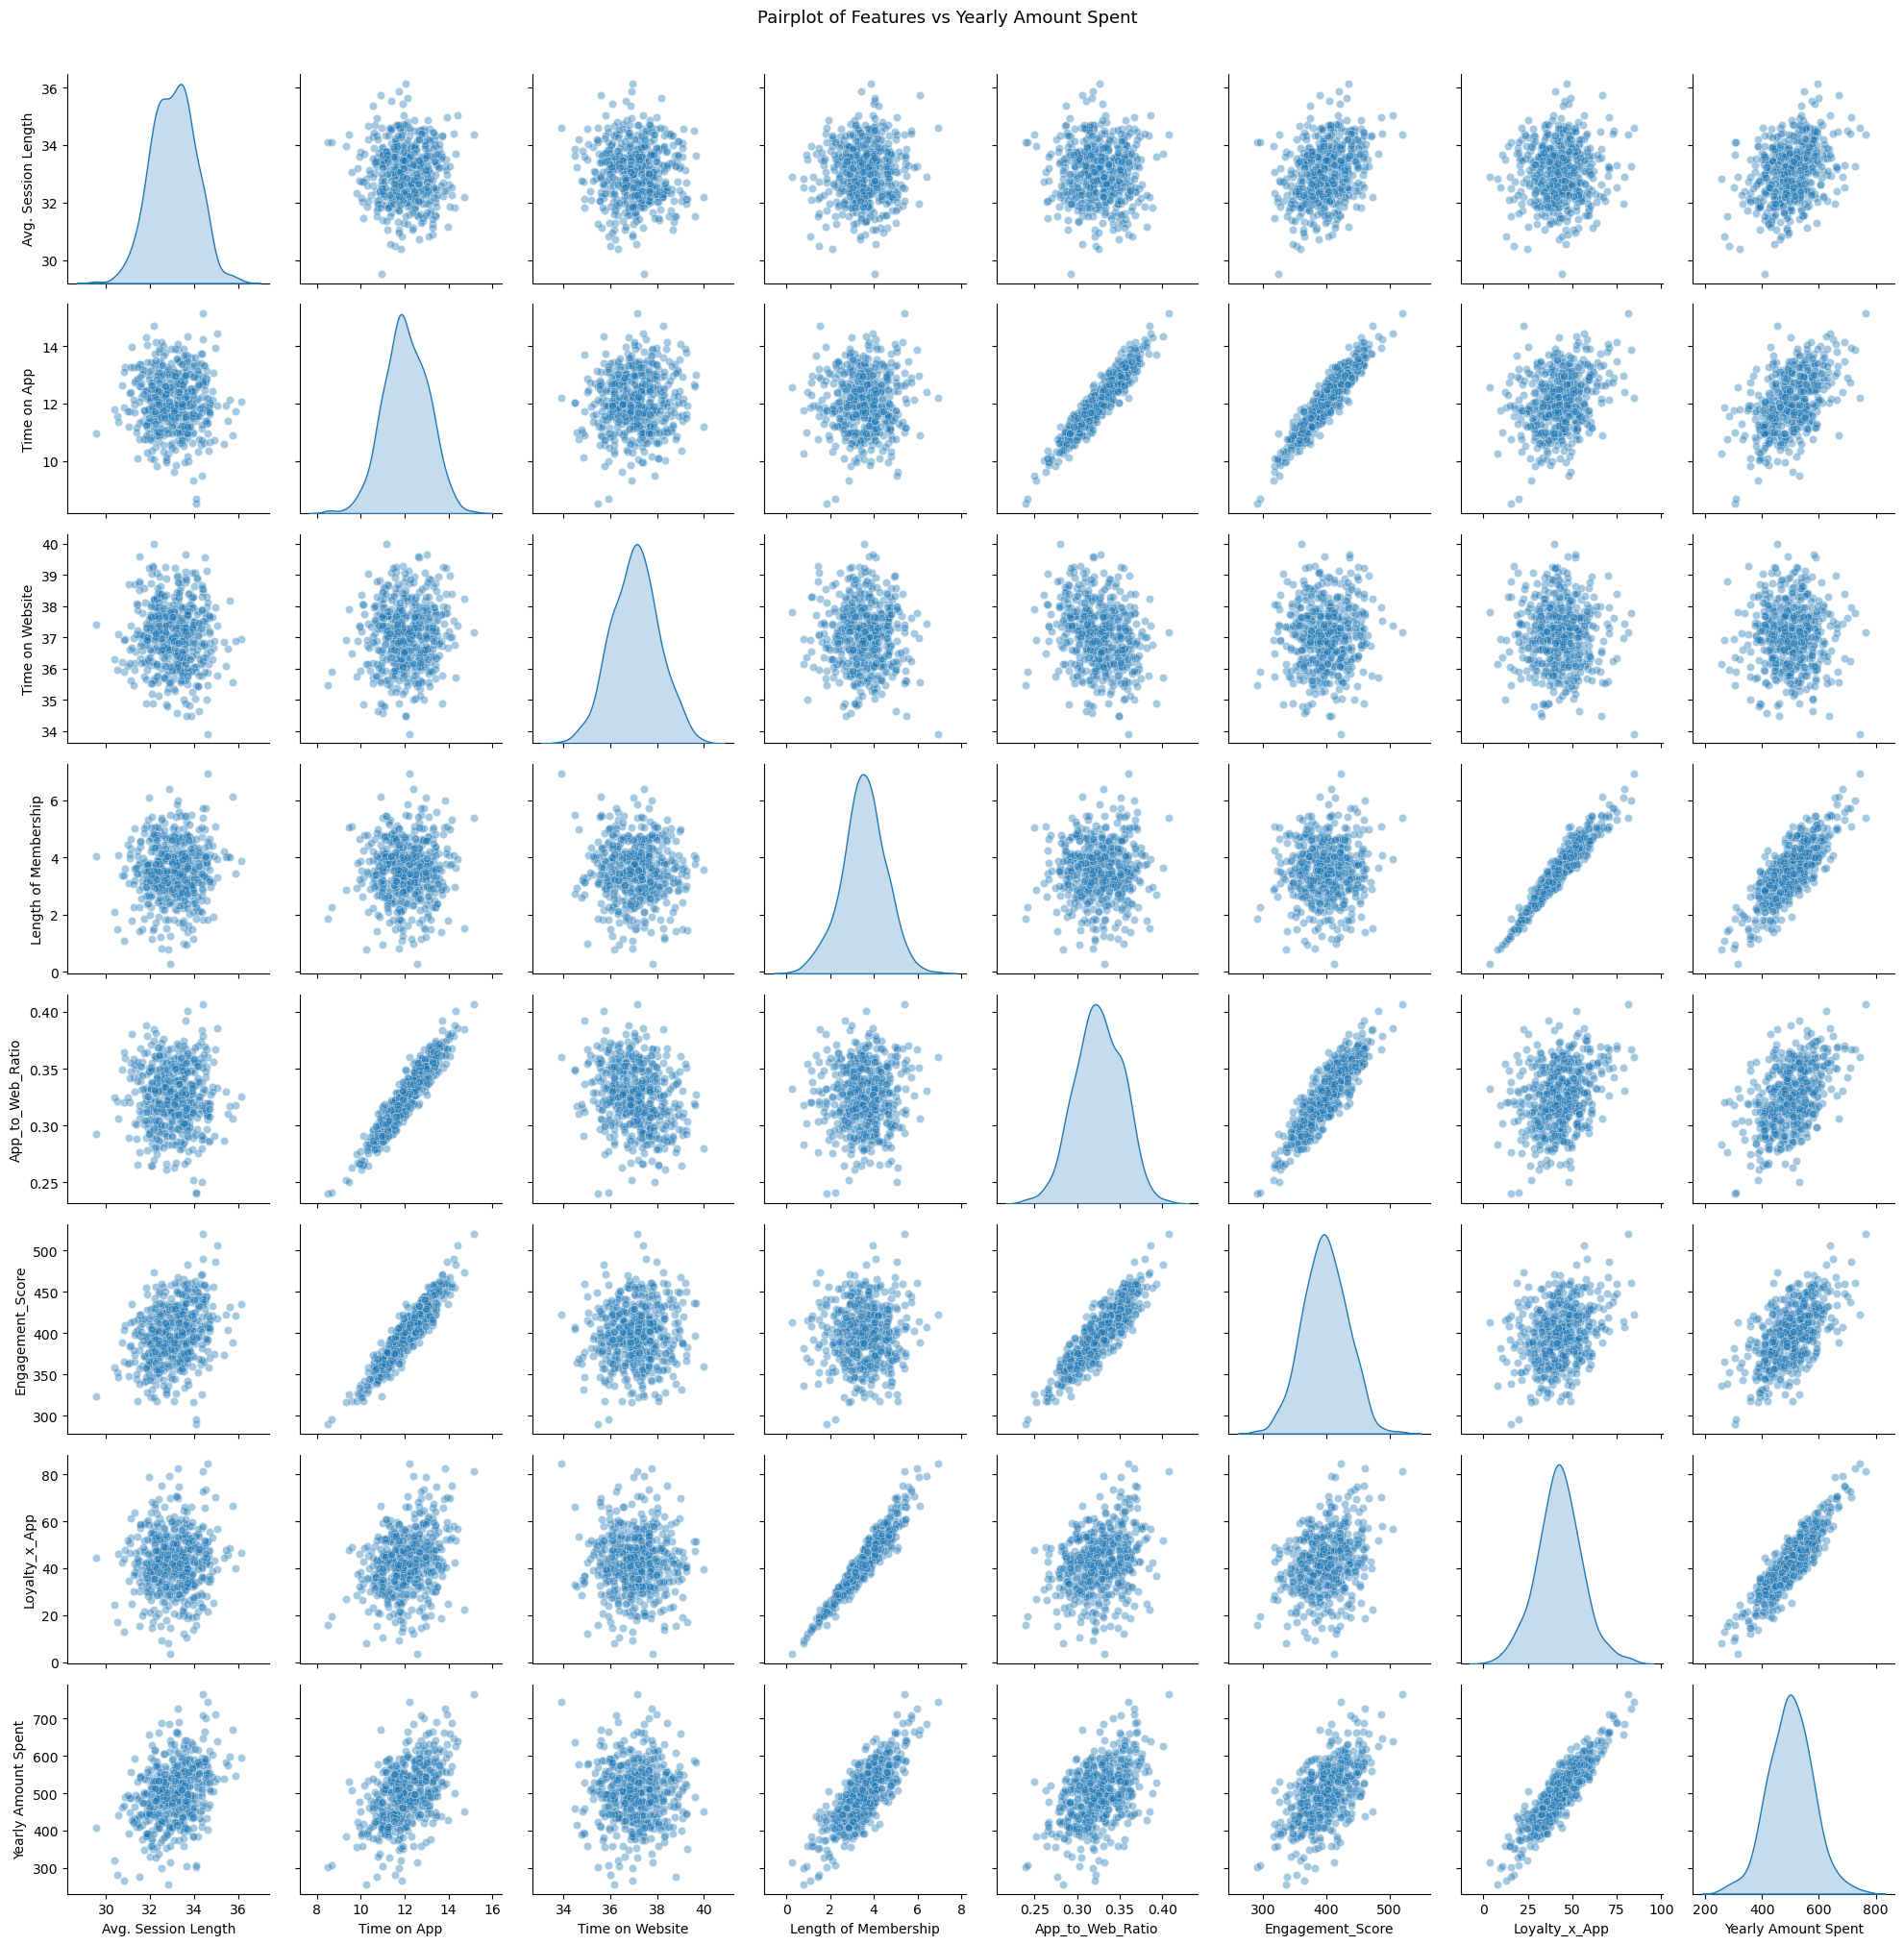

In [31]:
numeric_cols = [
    'Avg. Session Length', 'Time on App',
    'Time on Website', 'Length of Membership',
    'App_to_Web_Ratio', 'Engagement_Score',
    'Loyalty_x_App', 'Yearly Amount Spent'
]

sns.pairplot(df_clean[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Features vs Yearly Amount Spent', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Step 5.4 Correlation Heatmap

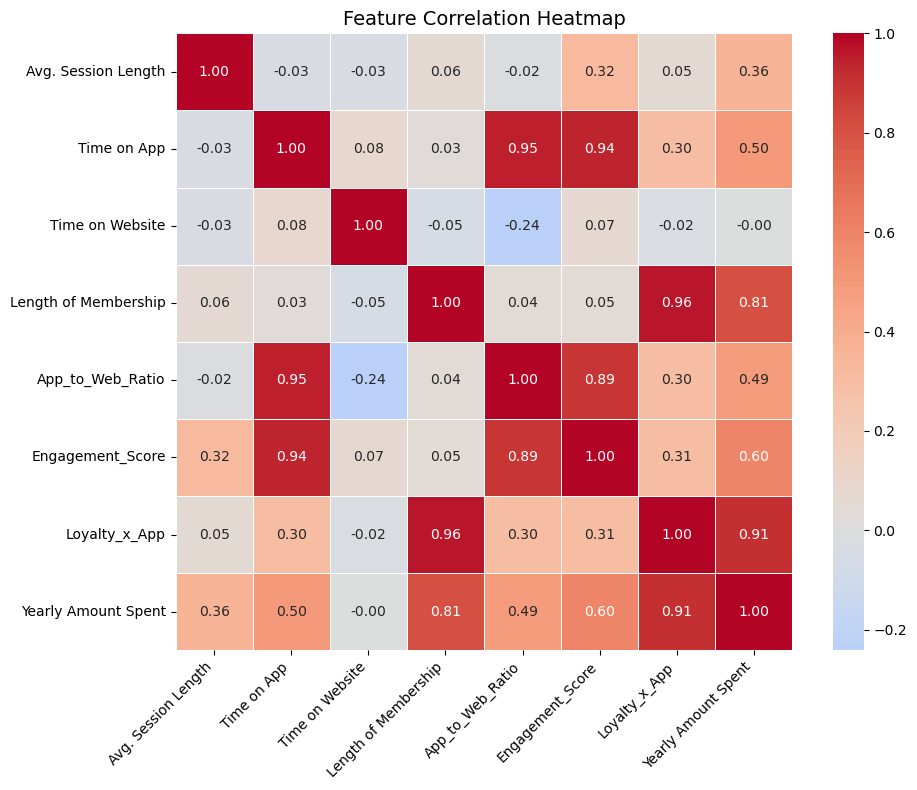

In [33]:
numeric_cols = [
    'Avg. Session Length', 'Time on App',
    'Time on Website',   'Length of Membership',
    'App_to_Web_Ratio',   'Engagement_Score',
    'Loyalty_x_App',      'Yearly Amount Spent'
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The heatmap highlights two important things:
Correlations with the target (last row/column):

Loyalty_x_App (+0.91) and Length of Membership (+0.81) are the strongest predictors
Time on Website (-0.00) has almost no relationship with spending

Multicollinearity warning (off-diagonal):

Time on App, App_to_Web_Ratio, and Engagement_Score are highly correlated with each other (0.89–0.95) — this is expected since the engineered features were derived from Time on App. Linear Regression can still work, but coefficients for these features may be less stable as a result.


## Step 5.5 — Train/Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=101
)

print("Training set :", X_train.shape, "→", len(X_train), "samples (60%)")
print("Test set     :", X_test.shape,  "→", len(X_test),  "samples (40%)")
print("\ny_train range: [{:.2f}, {:.2f}]".format(y_train.min(), y_train.max()))
print("y_test  range: [{:.2f}, {:.2f}]".format(y_test.min(),  y_test.max()))

Training set : (300, 9) → 300 samples (60%)
Test set     : (200, 9) → 200 samples (40%)

y_train range: [266.09, 725.58]
y_test  range: [256.67, 765.52]


# Task 6 — Train the Model

## Step 6.1 — Create and Fit the Model

In [35]:
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 6.2 — Inspect Coefficients

In [36]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df = coeff_df.sort_values('Coefficient', ascending=False)
print(coeff_df)

                         Coefficient
App_to_Web_Ratio          656.073562
Length of Membership       63.181587
Avg. Session Length        27.477583
Time on App                25.136760
Time on Website             6.326632
Loyalty_x_App              -0.067006
Engagement_Score           -0.142559
Membership_Tier_Regular    -2.289510
Membership_Tier_Loyal      -3.473406


## Step 6.3 — Make Predictions

In [37]:
predictions = lm.predict(X_test)

print("Sample predictions vs actual values:\n")
comparison = pd.DataFrame({
    'Actual'    : y_test.values[:10].round(2),
    'Predicted' : predictions[:10].round(2),
    'Error'     : (y_test.values[:10] - predictions[:10]).round(2)
})
print(comparison.to_string(index=False))

Sample predictions vs actual values:

 Actual  Predicted  Error
 452.32     454.74  -2.42
 401.03     406.63  -5.60
 410.07     411.02  -0.95
 599.41     590.63   8.77
 586.16     590.48  -4.33
 535.48     548.63 -13.15
 588.71     577.34  11.37
 712.40     713.18  -0.79
 462.90     473.16 -10.26
 532.72     545.67 -12.95


# Task 7 — Evaluate Model

## Step 7.1 — Regression Metrics

In [38]:
print('MAE :', round(metrics.mean_absolute_error(y_test, predictions), 4))
print('MSE :', round(metrics.mean_squared_error(y_test, predictions), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 4))
print('R²  :', round(metrics.r2_score(y_test, predictions), 4))

MAE : 7.7476
MSE : 93.248
RMSE: 9.6565
R²  : 0.9856


## Step 7.2 — Actual vs Predicted Scatter Plot

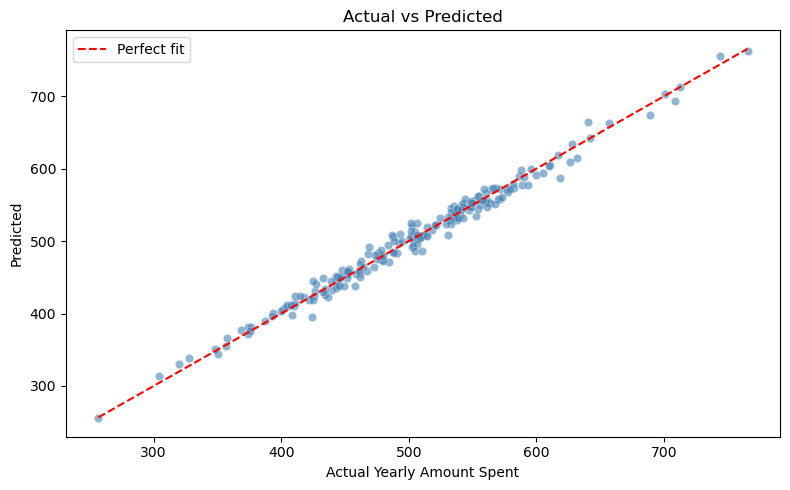

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7.3 — Residuals Histogram

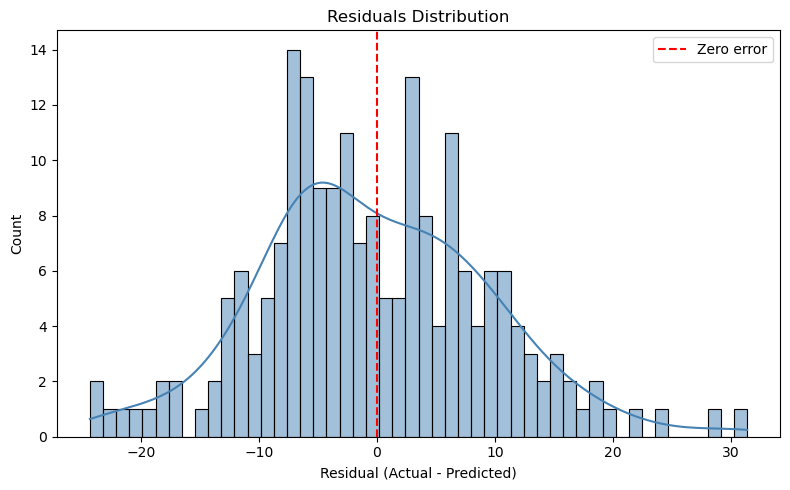

Residuals mean : -0.2988
Residuals std  : 9.6761


In [40]:
residuals = y_test - predictions

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Residuals Distribution')
plt.legend()
plt.tight_layout()
plt.show()

print("Residuals mean :", round(residuals.mean(), 4))
print("Residuals std  :", round(residuals.std(),  4))

## Step 7.4 — Interpret the Results

In [42]:
mae  = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r2   = metrics.r2_score(y_test, predictions)
mean_y = y_test.mean()

print("=== Model Interpretation ===")
print(f"\nAverage Yearly Spend (actual): ${mean_y:.2f}")
print(f"MAE  : ${mae:.2f}  → on average, predictions are off by ${mae:.2f}")
print(f"RMSE : ${rmse:.2f}  → typical prediction error is ${rmse:.2f}")
print(f"R²   : {r2:.4f} → the model explains {r2*100:.2f}% of spending variance")
print(f"\nError as % of mean: {(mae/mean_y)*100:.2f}% → very low, model is highly accurate")

=== Model Interpretation ===

Average Yearly Spend (actual): $502.97
MAE  : $7.75  → on average, predictions are off by $7.75
RMSE : $9.66  → typical prediction error is $9.66
R²   : 0.9856 → the model explains 98.56% of spending variance

Error as % of mean: 1.54% → very low, model is highly accurate
